In [33]:
# ruff: noqa: F401

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

In [34]:
# read in all the words
words = open("../public/names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [35]:
len(words)

32033

In [36]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set("".join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi["."] = 0
itos = {i: s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [37]:
# hyper parameters

# context length: how many characters do we take to predict the next one?
context_length = 3
emb_dim = 10
layer_size = 200
batch_size = 32
training_runs = 200000
learning_rate = 0.1
decayed_learning_rate = 0.01
decayed_lr_point = 0.5

In [38]:
# build the dataset


def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * context_length
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y


random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [39]:
g = torch.Generator().manual_seed(2147483647)  # for reproducibility

C = torch.randn((27, emb_dim), generator=g)
W1 = torch.randn((context_length * emb_dim, layer_size), generator=g)
b1 = torch.randn(layer_size, generator=g)
W2 = torch.randn((layer_size, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [40]:
sum(p.nelement() for p in parameters)  # number of parameters in total

11897

In [41]:
for p in parameters:
    p.requires_grad = True

In [42]:
lossi = []
stepi = []

In [ ]:
for i in range(training_runs):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 2)
    h = torch.tanh(emb.view(-1, context_length * emb_dim) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = (
        learning_rate if i < training_runs * decayed_lr_point else decayed_learning_rate
    )
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())

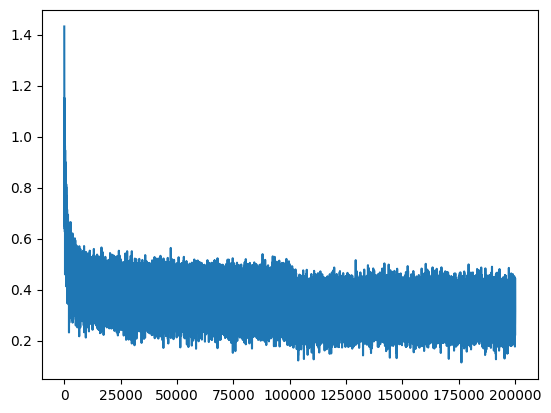

In [44]:
plt.plot(stepi, lossi)

In [45]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, context_length * emb_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss.item()

2.1254494190216064

In [46]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, context_length * emb_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss.item()

2.1679446697235107

In [47]:
emb = C[Xte]
h = torch.tanh(emb.view(-1, context_length * emb_dim) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss.item()

2.1686410903930664

In [48]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * context_length  # initialize with all ...
    while True:
        emb = C[torch.tensor([context])]  # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

carmah.
qui.
hariha.
mili.
taty.
skaelane.
mahuen.
delynn.
jareei.
nellara.
chaiiv.
kaleigh.
ham.
pori.
quintis.
line.
liveni.
wazelo.
dearisi.
jaceenissa.
